# L06 · Evaluation, Leakage and Honest Validation

*Companion notebook for Lecture 6 — Model Evaluation and Experimental Design (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**
1. Watch leakage turn pure noise into a "90%-accurate" gene signature — and remove it with a pipeline.
2. See why several samples per patient require patient-level (grouped) splits, and why tuned hyperparameters need nested CV.
3. Compare ROC and precision–recall curves when positives are rare; choose a threshold from costs.
4. Put confidence intervals on AUC and accuracy with the bootstrap.
5. Check calibration and read a learning curve.

Every experiment, seed and number follows `slides_src/lectures/L06_evaluation.py`, so the printed values match the slides.
Everything runs in about a minute on a laptop CPU (no GPU needed).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.datasets import load_breast_cancer
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                             confusion_matrix, brier_score_loss)
from sklearn.model_selection import (StratifiedKFold, KFold, GroupKFold, GridSearchCV, cross_val_score,
                                     cross_val_predict, train_test_split, learning_curve, StratifiedShuffleSplit)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from course_utils import seed_everything, plot_style, load_tcga, PALETTE

rng = seed_everything(0)
plot_style()
C_HONEST, C_LEAKY, C_CASE, C_CTRL = PALETTE[2], PALETTE[5], PALETTE[5], PALETTE[0]

## Datasets

Evaluation mistakes are easiest to see when the right answer is known, so most experiments use **synthetic data**
generated in the notebook. Two real public datasets are used as well:

- **Breast biopsies** — Wisconsin Diagnostic Breast Cancer (Street, Wolberg & Mangasarian 1993; UCI Machine Learning
  Repository, CC BY 4.0; bundled with scikit-learn as `load_breast_cancer`). **One sample** = one fine-needle aspirate
  of a breast mass; **input** = 30 summary statistics of cell-nucleus size, shape and texture from a digitized image;
  **target** $y = 1$ malignant, $0$ benign (scikit-learn codes malignant as 0, so we use `y = 1 - target`).
  569 biopsies, 212 malignant (37%). Why it matters: a missed cancer and an unnecessary biopsy have very different
  costs, so accuracy alone is not enough.
- **TCGA tumors** — UCI "gene expression cancer RNA-Seq" extract of The Cancer Genome Atlas PANCAN data
  (Weinstein et al., *Nat. Genet.* 2013; UCI, CC BY 4.0), loaded with `course_utils.load_tcga()` (cached from L02).
  801 tumors × 20,531 genes. Here we use **real expression profiles with random labels**, so the true accuracy is 50%.

## Exploration: the breast-biopsy data

n = 569 biopsies, d = 30 features; malignant fraction 0.373


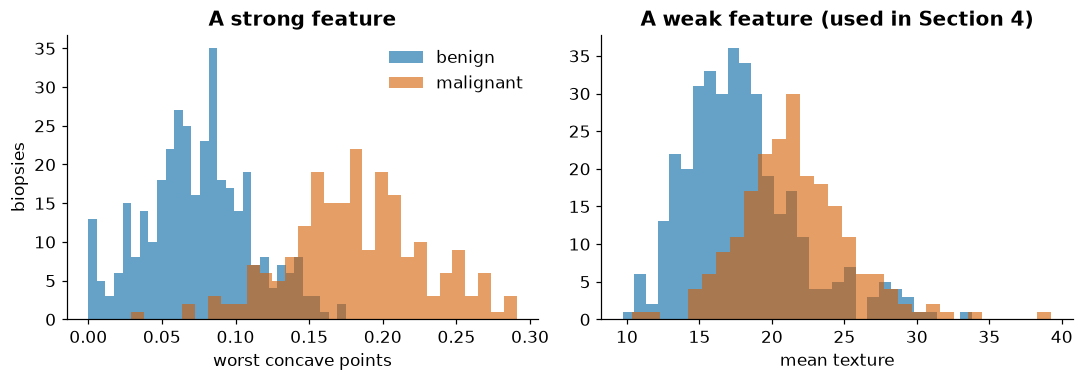

In [2]:
bc = load_breast_cancer()
Xb, yb, names = bc.data, 1 - bc.target, list(bc.feature_names)
print(f"n = {Xb.shape[0]} biopsies, d = {Xb.shape[1]} features; malignant fraction {yb.mean():.3f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for k, (lab, col) in enumerate([("benign", C_CTRL), ("malignant", C_CASE)]):
    ax[0].hist(Xb[yb == k, names.index("worst concave points")], bins=30, alpha=0.6, color=col, label=lab)
    ax[1].hist(Xb[yb == k, names.index("mean texture")], bins=30, alpha=0.6, color=col, label=lab)
ax[0].set(xlabel="worst concave points", ylabel="biopsies", title="A strong feature")
ax[1].set(xlabel="mean texture", title="A weak feature (used in Section 4)")
ax[0].legend(); plt.tight_layout(); plt.show()

## 1. Leakage: feature selection before splitting

**Data (synthetic, so we know the truth).** Imagine a small gene-expression study: $n = 60$ patients, $d = 5{,}000$ genes, and a binary label (e.g., responder vs. non-responder). Here every "gene" is independent Gaussian noise and the labels are random, so **no classifier can beat 50% on new patients**.

**Model.** Logistic regression on the $k = 20$ genes with the largest F-statistic, scored by 5-fold cross-validation — in two ways:
- **Leaky:** pick the 20 genes using *all 60 labels*, then cross-validate logistic regression on those genes.
- **Honest:** put the gene selection *inside* the pipeline, so it is redone on the training folds of each split.

This is the selection bias described by Ambroise & McLachlan (*PNAS* 2002).

In [3]:
K_GENES = 20        # genes kept by SelectKBest (Try it yourself: 200)

def noise_study(seed, n=60, d=5000):
    r = np.random.default_rng(seed)
    X = r.normal(size=(n, d))
    y = r.permutation(np.r_[np.zeros(n // 2), np.ones(n // 2)]).astype(int)
    return X, y

def leaky_and_honest(X, y, seed, k=K_GENES):
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    top = SelectKBest(f_classif, k=k).fit(X, y).get_support()           # looks at ALL labels -> leak
    leaky = cross_val_score(LogisticRegression(max_iter=2000), X[:, top], y, cv=cv).mean()
    pipe = make_pipeline(SelectKBest(f_classif, k=k), LogisticRegression(max_iter=2000))
    honest = cross_val_score(pipe, X, y, cv=cv).mean()                  # selection refit in each fold
    return leaky, honest

X, y = noise_study(0)
print("one study: leaky = %.3f, honest = %.3f" % leaky_and_honest(X, y, 0))

one study: leaky = 0.933, honest = 0.417


One study could be a fluke. Repeat the whole experiment on 50 independent noise datasets and look at the distribution.

leaky : mean 0.945  (min 0.88, max 1.00)
honest: mean 0.486  (min 0.30, max 0.70)


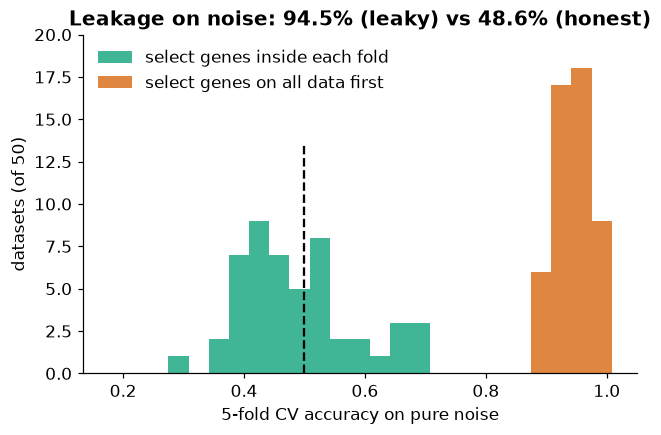

In [4]:
res = np.array([leaky_and_honest(*noise_study(s), s) for s in range(50)])
print(f"leaky : mean {res[:, 0].mean():.3f}  (min {res[:, 0].min():.2f}, max {res[:, 0].max():.2f})")
print(f"honest: mean {res[:, 1].mean():.3f}  (min {res[:, 1].min():.2f}, max {res[:, 1].max():.2f})")
bins = (np.arange(10, 62, 2) + 0.5) / 60          # CV accuracy on 60 samples is a multiple of 1/60
plt.figure(figsize=(6.5, 4))
plt.hist(res[:, 1], bins=bins, alpha=0.75, label="select genes inside each fold", color=C_HONEST)
plt.hist(res[:, 0], bins=bins, alpha=0.75, label="select genes on all data first", color=C_LEAKY)
plt.axvline(0.5, ymax=0.68, color="k", ls="--"); plt.ylim(0, 20); plt.xlabel("5-fold CV accuracy on pure noise"); plt.ylabel("datasets (of 50)")
plt.title(f"Leakage on noise: {res[:, 0].mean():.1%} (leaky) vs {res[:, 1].mean():.1%} (honest)")
plt.legend(loc="upper left"); plt.show()

The leaky pipeline reports high accuracy on data with **no signal at all**. The honest estimates are centred on 50% but spread widely — with 60 patients, even an honest CV estimate is noisy.

**Why does the leak work?** With 5,000 genes, a few will separate these particular 60 labels by chance. Choosing them with all labels means the test folds helped pick the features.

### Same experiment on real tumors with shuffled labels
Independent Gaussian genes are unrealistic: real genes are correlated. Take 60 real TCGA tumors (all 20,531 genes), give them **random** labels, and repeat (20 sets, as on the slide).

In [5]:
Xt, _, _ = load_tcga()
tc = []
with warnings.catch_warnings():
    # some genes are zero in all 60 tumors (or in a training fold): their F-statistic is undefined (NaN) and
    # SelectKBest simply never picks them -- harmless, so we silence the "constant features" warnings
    warnings.simplefilter("ignore", category=UserWarning)
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for s in range(20):
        r = np.random.default_rng(100 + s)
        idx = r.choice(Xt.shape[0], 60, replace=False)
        lab = r.permutation(np.r_[np.zeros(30), np.ones(30)]).astype(int)   # random labels on real tumors
        tc.append(leaky_and_honest(Xt[idx].astype(float), lab, s))
tc = np.array(tc)
print(f"TCGA, {Xt.shape[1]:,} genes, random labels: leaky {tc[:, 0].mean():.1%} vs honest {tc[:, 1].mean():.1%} (20 sets)")
del Xt

TCGA, 20,531 genes, random labels: leaky 79.8% vs honest 49.4% (20 sets)


## 2. Patient-level splits: repeated measures

**Data (synthetic).** 30 patients (15 with disease), 8 samples each — think 8 tissue tiles, 8 cells or 8 visits. Every patient has their own offset across 50 features (biological individuality, sample handling); the disease adds a weak shift to 5 features.

- `KFold` on *samples* puts samples of the same patient in both training and test folds.
- `GroupKFold` with `groups = patient id` keeps each patient entirely on one side.

In [6]:
SAMPLES_PER_PATIENT = 8     # Try it yourself: 2

def patient_study(seed, P=30, m=SAMPLES_PER_PATIENT, d=50, eff=1.0, sp=1.0, sw=0.3):
    r = np.random.default_rng(seed)
    yp = r.permutation(np.r_[np.zeros(P // 2), np.ones(P // 2)]).astype(int)
    offset = r.normal(0, sp, (P, d))                 # patient-specific signature
    mu = np.zeros(d); mu[:5] = eff                    # weak disease effect
    X = np.repeat(offset + yp[:, None] * mu, m, 0) + r.normal(0, sw, (P * m, d))
    return X, np.repeat(yp, m), np.repeat(np.arange(P), m)

logreg = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
rows = []
for s in range(20):
    Xg, yg, g = patient_study(s)
    rnd = cross_val_score(logreg(), Xg, yg, cv=KFold(5, shuffle=True, random_state=s)).mean()
    grp = cross_val_score(logreg(), Xg, yg, cv=GroupKFold(5), groups=g).mean()
    rows.append((rnd, grp))
rows = np.array(rows)
print(f"random split of samples: {rows[:, 0].mean():.2f}")
print(f"GroupKFold by patient  : {rows[:, 1].mean():.2f}   (mean of 20 synthetic studies)")

random split of samples: 1.00
GroupKFold by patient  : 0.70   (mean of 20 synthetic studies)


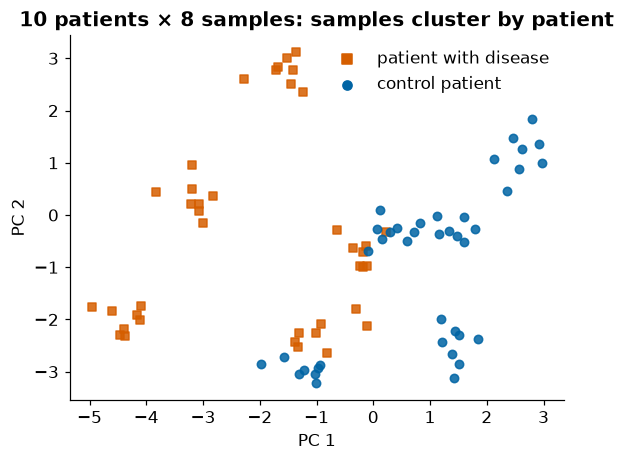

In [7]:
Xg, yg, g = patient_study(0)
Z = StandardScaler().fit_transform(Xg)
U, S_, Vt = np.linalg.svd(Z - Z.mean(0), full_matrices=False)
pc = U[:, :2] * S_[:2]
plt.figure(figsize=(5.8, 4.3))
for p in range(10):
    m = g == p
    plt.scatter(*pc[m].T, s=30, marker="s" if yg[m][0] else "o", color=C_CASE if yg[m][0] else C_CTRL, alpha=0.85)
plt.scatter([], [], color=C_CASE, marker="s", label="patient with disease")
plt.scatter([], [], color=C_CTRL, marker="o", label="control patient")
plt.legend(); plt.title(f"10 patients × {SAMPLES_PER_PATIENT} samples: samples cluster by patient")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.show()

Samples cluster by **patient**. A random split lets the model match a test sample to its twin in the training set. Only the grouped estimate answers the clinical question: *how well does it work for a new patient?*

## 3. Tuning hyperparameters: nested cross-validation
If we try 30 kNN settings and report the best CV score, the test folds were used to choose the model. Nested CV runs the whole search inside each outer training fold. Data: pure noise again (60 samples × 100 features, balanced random labels), so the truth is 50%.

In [8]:
grid = {"kneighborsclassifier__n_neighbors": list(range(1, 30, 2)),
        "kneighborsclassifier__weights": ["uniform", "distance"]}          # 15 × 2 = 30 settings
nest = []
for s in range(20):
    r = np.random.default_rng(500 + s)
    Xn = r.normal(size=(60, 100))
    yn = r.permutation(np.r_[np.zeros(30), np.ones(30)]).astype(int)
    gs = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()), grid,
                      cv=StratifiedKFold(5, shuffle=True, random_state=s), n_jobs=4).fit(Xn, yn)   # 4 parallel workers
    outer = cross_val_score(gs, Xn, yn, cv=StratifiedKFold(5, shuffle=True, random_state=s + 100)).mean()
    nest.append((gs.best_score_, outer))
nest = np.array(nest)
print(f"best inner CV score {nest[:, 0].mean():.2f}  vs  nested CV estimate {nest[:, 1].mean():.2f}  (mean of 20 datasets)")

best inner CV score 0.58  vs  nested CV estimate 0.49  (mean of 20 datasets)


## 4. Breast-biopsy data: metrics, ROC and PR curves

**Preprocessing and model.** One stratified 70/30 split (`random_state=0`), then a pipeline `StandardScaler → LogisticRegression` (L2, C = 1), so the scaler only sees training biopsies. **Evaluation** at threshold 0.5.

In [9]:
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=0, stratify=yb)
clf = logreg().fit(Xtr, ytr)
p_te = clf.predict_proba(Xte)[:, 1]
tn, fp, fn, tp = confusion_matrix(yte, p_te >= 0.5).ravel()
print(f"{len(ytr)} training / {len(yte)} test biopsies")
print(f"TP {tp}  FN {fn}  FP {fp}  TN {tn}")
print(f"accuracy {(tp + tn) / len(yte):.3f}  sensitivity {tp / (tp + fn):.3f}  specificity {tn / (tn + fp):.3f}  "
      f"precision {tp / (tp + fp):.3f}")
print(f"test AUC {roc_auc_score(yte, p_te):.3f}")

398 training / 171 test biopsies
TP 60  FN 4  FP 4  TN 103
accuracy 0.953  sensitivity 0.938  specificity 0.963  precision 0.938
test AUC 0.992


### ROC vs PR under class imbalance
The full model is almost perfect, so to see the difference clearly we use a **weaker** model with only two features (mean texture, mean smoothness) and out-of-fold predictions for all 569 biopsies. Then we keep every benign biopsy and subsample malignant ones so that they are 5% of the evaluation set. The scores do not change — only the prevalence.

357 benign + 19 malignant in each 5% subsample
all data : AUC 0.831, AP 0.729
5% prev. : AUC 0.834, AP 0.260 ± 0.067 (200 subsamples)


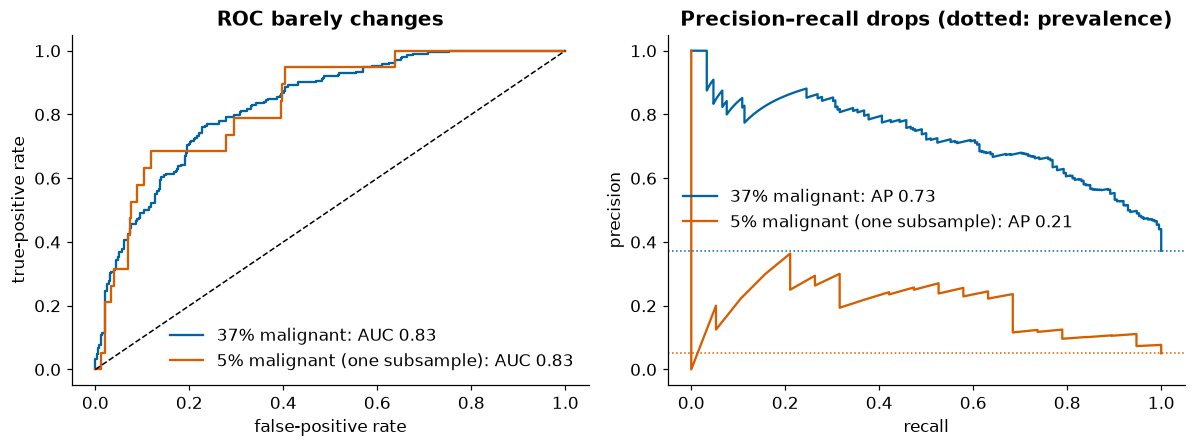

In [10]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
idx = [names.index("mean texture"), names.index("mean smoothness")]
s_weak = cross_val_predict(logreg(), Xb[:, idx], yb, cv=cv, method="predict_proba")[:, 1]
neg, pos = np.where(yb == 0)[0], np.where(yb == 1)[0]
m5 = int(round(0.05 / 0.95 * len(neg)))
r1 = np.random.default_rng(1)
reps = []
for _ in range(200):
    sel_r = np.r_[neg, r1.choice(pos, m5, replace=False)]
    reps.append((roc_auc_score(yb[sel_r], s_weak[sel_r]), average_precision_score(yb[sel_r], s_weak[sel_r])))
reps = np.array(reps)
print(f"{len(neg)} benign + {m5} malignant in each 5% subsample")
print(f"all data : AUC {roc_auc_score(yb, s_weak):.3f}, AP {average_precision_score(yb, s_weak):.3f}")
print(f"5% prev. : AUC {reps[:, 0].mean():.3f}, AP {reps[:, 1].mean():.3f} ± {reps[:, 1].std():.3f} (200 subsamples)")

sel = np.r_[neg, np.random.default_rng(2).choice(pos, m5, replace=False)]      # the subsample drawn on the slide
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for yy, ss, lab, col in [(yb, s_weak, f"{yb.mean():.0%} malignant", PALETTE[0]),
                         (yb[sel], s_weak[sel], "5% malignant (one subsample)", PALETTE[5])]:
    fpr, tpr, _ = roc_curve(yy, ss); pr, rc, _ = precision_recall_curve(yy, ss)
    ax[0].plot(fpr, tpr, color=col, label=f"{lab}: AUC {roc_auc_score(yy, ss):.2f}")
    ax[1].plot(rc, pr, color=col, label=f"{lab}: AP {average_precision_score(yy, ss):.2f}")
    ax[1].axhline(yy.mean(), color=col, ls=":", lw=1)
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set(xlabel="false-positive rate", ylabel="true-positive rate", title="ROC barely changes")
ax[1].set(xlabel="recall", ylabel="precision", title="Precision–recall drops (dotted: prevalence)")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

ROC-AUC barely moves; average precision falls sharply. At 5% prevalence each true detection comes with many more false alarms, which precision reports and specificity hides.

### Choosing a threshold from costs
Suppose missing a cancer costs 10 times as much as an unnecessary biopsy: $c_{\mathrm{FN}} = 10$, $c_{\mathrm{FP}} = 1$. Lecture 3's rule says: predict malignant when $p > c_{\mathrm{FP}}/(c_{\mathrm{FP}} + c_{\mathrm{FN}}) = 1/11 \approx 0.09$. We check it with out-of-fold probabilities of the full model (in practice, choose the threshold on validation data, never on the test set). The 10:1 ratio is an illustration, not a clinical recommendation.

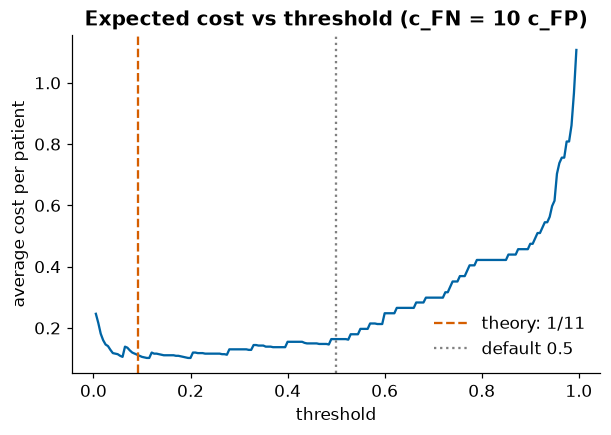

empirical cost minimum at t = 0.11
threshold 0.50: sensitivity 0.958, specificity 0.992, missed cancers 9, false alarms 3
threshold 0.09: sensitivity 0.986, specificity 0.905, missed cancers 3, false alarms 34


In [11]:
p_oof = cross_val_predict(logreg(), Xb, yb, cv=cv, method="predict_proba")[:, 1]
ts = np.linspace(0.005, 0.995, 199)
cost = np.array([(10 * ((p_oof < t) & (yb == 1)).sum() + 1 * ((p_oof >= t) & (yb == 0)).sum()) / len(yb) for t in ts])
plt.figure(figsize=(6.2, 4))
plt.plot(ts, cost, color=PALETTE[0]); plt.axvline(1 / 11, color=PALETTE[5], ls="--", label="theory: 1/11")
plt.axvline(0.5, color="gray", ls=":", label="default 0.5")
plt.xlabel("threshold"); plt.ylabel("average cost per patient"); plt.title("Expected cost vs threshold (c_FN = 10 c_FP)")
plt.legend(); plt.show()
print(f"empirical cost minimum at t = {ts[cost.argmin()]:.2f}")
for t in [0.5, 1 / 11]:
    yh = p_oof >= t
    print(f"threshold {t:.2f}: sensitivity {(yh & (yb == 1)).sum() / (yb == 1).sum():.3f}, "
          f"specificity {(~yh & (yb == 0)).sum() / (yb == 0).sum():.3f}, missed cancers {(~yh & (yb == 1)).sum()}, "
          f"false alarms {(yh & (yb == 0)).sum()}")

## 5. Confidence intervals: bootstrap and exact binomial
Resample the test biopsies with replacement ($B = 2{,}000$), recompute the metric, and take the 2.5th and 97.5th percentiles. Set `N_TEST_BOOT = 50` to bootstrap a random subset of only 50 test biopsies (Try it yourself).

171 test biopsies: AUC 0.992, accuracy 163/171 = 0.953
AUC     : 95% bootstrap CI [0.980, 0.999]
accuracy: 95% bootstrap CI [0.924, 0.982]
accuracy: exact binomial CI  [0.910, 0.980]


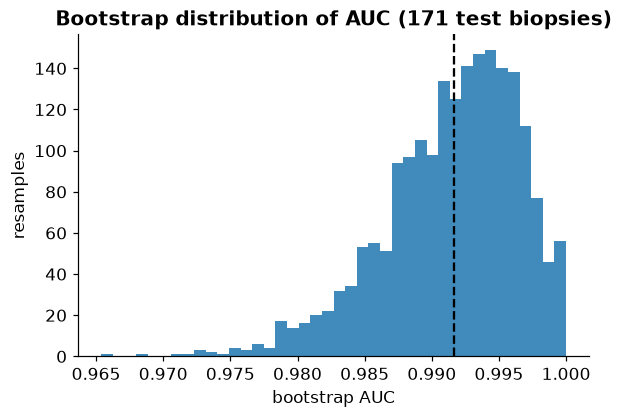

In [12]:
N_TEST_BOOT = None       # None = all 171 test biopsies; Try it yourself: 50

yh_te = (p_te >= 0.5).astype(int)
rb = np.random.default_rng(0)
use = np.arange(len(yte)) if N_TEST_BOOT is None else np.random.default_rng(3).choice(len(yte), N_TEST_BOOT, replace=False)
yt_, pt_, yh_ = yte[use], p_te[use], yh_te[use]
boot = []
for _ in range(2000):
    i = rb.integers(0, len(yt_), len(yt_))
    if yt_[i].min() == yt_[i].max():          # AUC needs both classes
        continue
    boot.append((roc_auc_score(yt_[i], pt_[i]), (yh_[i] == yt_[i]).mean()))
boot = np.array(boot)
k = int((yh_ == yt_).sum())
ci = binomtest(k, len(yt_)).proportion_ci(0.95, method="exact")
print(f"{len(yt_)} test biopsies: AUC {roc_auc_score(yt_, pt_):.3f}, accuracy {k}/{len(yt_)} = {k / len(yt_):.3f}")
for j, name in enumerate(["AUC", "accuracy"]):
    lo, hi = np.percentile(boot[:, j], [2.5, 97.5])
    print(f"{name:8s}: 95% bootstrap CI [{lo:.3f}, {hi:.3f}]")
print(f"accuracy: exact binomial CI  [{ci.low:.3f}, {ci.high:.3f}]")
plt.figure(figsize=(6, 3.8))
plt.hist(boot[:, 0], bins=40, color=PALETTE[0], alpha=0.75)
plt.axvline(roc_auc_score(yt_, pt_), color="k", ls="--")
plt.xlabel("bootstrap AUC"); plt.ylabel("resamples"); plt.title(f"Bootstrap distribution of AUC ({len(yt_)} test biopsies)")
plt.show()

**Why $n_\text{test} = 50$ is not enough.** The exact binomial interval for an observed accuracy of 0.90 shrinks only like $1/\sqrt{n}$:

In [13]:
for n in [50, 200, 1000]:
    c = binomtest(int(0.9 * n), n).proportion_ci(method="exact")
    print(f"accuracy 0.90 on n = {n:4d}: exact CI [{c.low:.3f}, {c.high:.3f}]")

accuracy 0.90 on n =   50: exact CI [0.782, 0.967]
accuracy 0.90 on n =  200: exact CI [0.850, 0.938]
accuracy 0.90 on n = 1000: exact CI [0.880, 0.918]


## 6. Calibration
Do predicted probabilities match observed frequencies? Compare logistic regression with Gaussian naive Bayes (Lecture 3), using out-of-fold predictions (same folds as above). The Brier score is the mean squared error of the probabilities (lower is better).

logistic regression    Brier 0.020   AUC 0.995
Gaussian naive Bayes   Brier 0.057   AUC 0.987


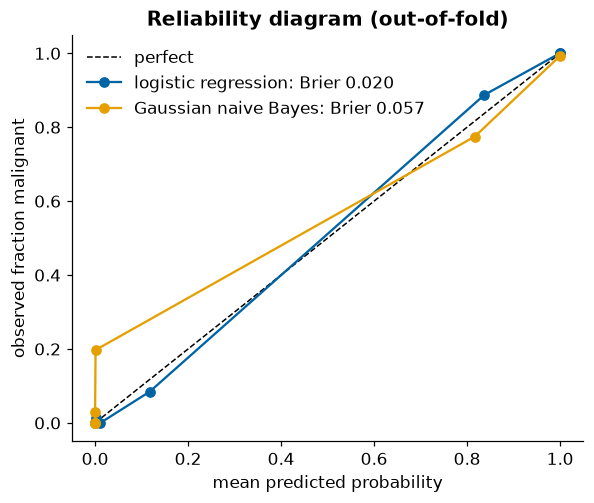

In [14]:
p_gnb = cross_val_predict(GaussianNB(), Xb, yb, cv=cv, method="predict_proba")[:, 1]
plt.figure(figsize=(6, 4.8))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for p, lab, col in [(p_oof, "logistic regression", PALETTE[0]), (p_gnb, "Gaussian naive Bayes", PALETTE[1])]:
    frac, mean_p = calibration_curve(yb, p, n_bins=8, strategy="quantile")
    plt.plot(mean_p, frac, "o-", color=col, label=f"{lab}: Brier {brier_score_loss(yb, p):.3f}")
    print(f"{lab:22s} Brier {brier_score_loss(yb, p):.3f}   AUC {roc_auc_score(yb, p):.3f}")
plt.xlabel("mean predicted probability"); plt.ylabel("observed fraction malignant")
plt.title("Reliability diagram (out-of-fold)"); plt.legend(); plt.show()

Both models rank biopsies well (similar AUC), but naive Bayes pushes its probabilities towards 0 and 1 — it double-counts correlated nucleus features. A cost-based threshold needs calibrated probabilities.

## 7. Learning curve
Would more biopsies help? Plot training and validation accuracy against training-set size (20 random 80/20 splits).

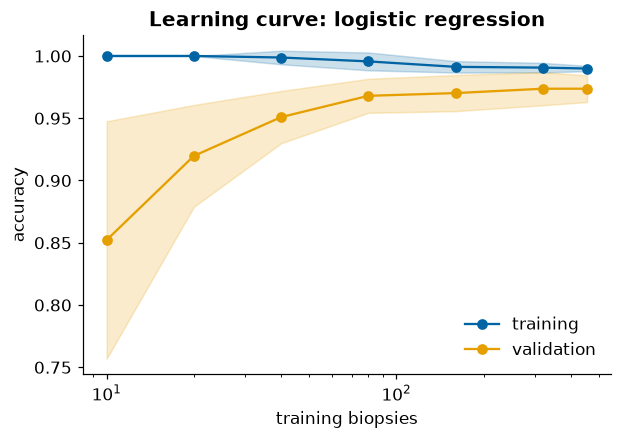

validation accuracy by size: {10: 0.852, 20: 0.92, 40: 0.951, 80: 0.968, 160: 0.97, 320: 0.974, 455: 0.974}


In [15]:
sizes, tr, va = learning_curve(logreg(), Xb, yb, train_sizes=[10, 20, 40, 80, 160, 320, 455],
                               cv=StratifiedShuffleSplit(20, test_size=0.2, random_state=0), shuffle=True,
                               random_state=0)
plt.figure(figsize=(6.2, 4))
for arr, lab, col in [(tr, "training", PALETTE[0]), (va, "validation", PALETTE[1])]:
    plt.plot(sizes, arr.mean(1), "o-", color=col, label=lab)
    plt.fill_between(sizes, arr.mean(1) - arr.std(1), arr.mean(1) + arr.std(1), color=col, alpha=0.2)
plt.xscale("log"); plt.xlabel("training biopsies"); plt.ylabel("accuracy"); plt.title("Learning curve: logistic regression")
plt.legend(); plt.show()
print("validation accuracy by size:", dict(zip(sizes.tolist(), va.mean(1).round(3).tolist())))

## 8. Biological interpretation
- Gene-expression studies have $d \gg n$. With thousands of candidate genes, some will separate any small set of labels by chance; only a selection step that never sees the test samples gives an honest estimate. Real, correlated expression profiles leak just as badly as independent noise.
- A "sample" is often not a patient: tiles of a slide, cells from a donor and repeated visits are correlated. Split and bootstrap by patient.
- Prevalence in a curated study (37% malignant here) is much higher than in screening. Precision and calibration change with prevalence; sensitivity and specificity do not.
- None of these checks protects against confounding (batch, hospital, scanner) that is shared by training and test data. That needs external or site-held-out validation.

## 9. Try it yourself
From the lecture:
1. Select 200 genes instead of 20. Does the leak grow? (Set `K_GENES = 200` in Section 1.)
2. Give each patient 2 samples instead of 8. (Set `SAMPLES_PER_PATIENT = 2` in Section 2.)
3. Bootstrap with only 50 test biopsies. (Set `N_TEST_BOOT = 50` in Section 5; how wide is the AUC interval now?)

More:
4. Replace `SelectKBest` in the leaky pipeline by a `StandardScaler` fitted on all data (no label use). Is the optimism still there?
5. In Section 2, make the patient offsets smaller (`sp=0.3`). When does the random split stop being optimistic?
6. *(CS284A)* Use nested cross-validation to tune the regularization strength `C` of the biopsy logistic model (`GridSearchCV` inside `cross_val_score`) and compare the nested estimate with the best inner CV score. Why is the gap much smaller than on noise?